Differential Equation Simulation
1. Simulate SHM (ion in harmonic potential); compare with analytical solution
2. Simulate dark matter trajectory using ion trap potential with random initial condition; check energy conservation
3. Simulate Rutherford scattering without the potential; use an ODE package to solve a coupled system

In [28]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z0 = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
eps = 1
alpha = 1/137.06
m_dm = 2.873e-25
m_ion = c.m 
Z_charge = c.Z

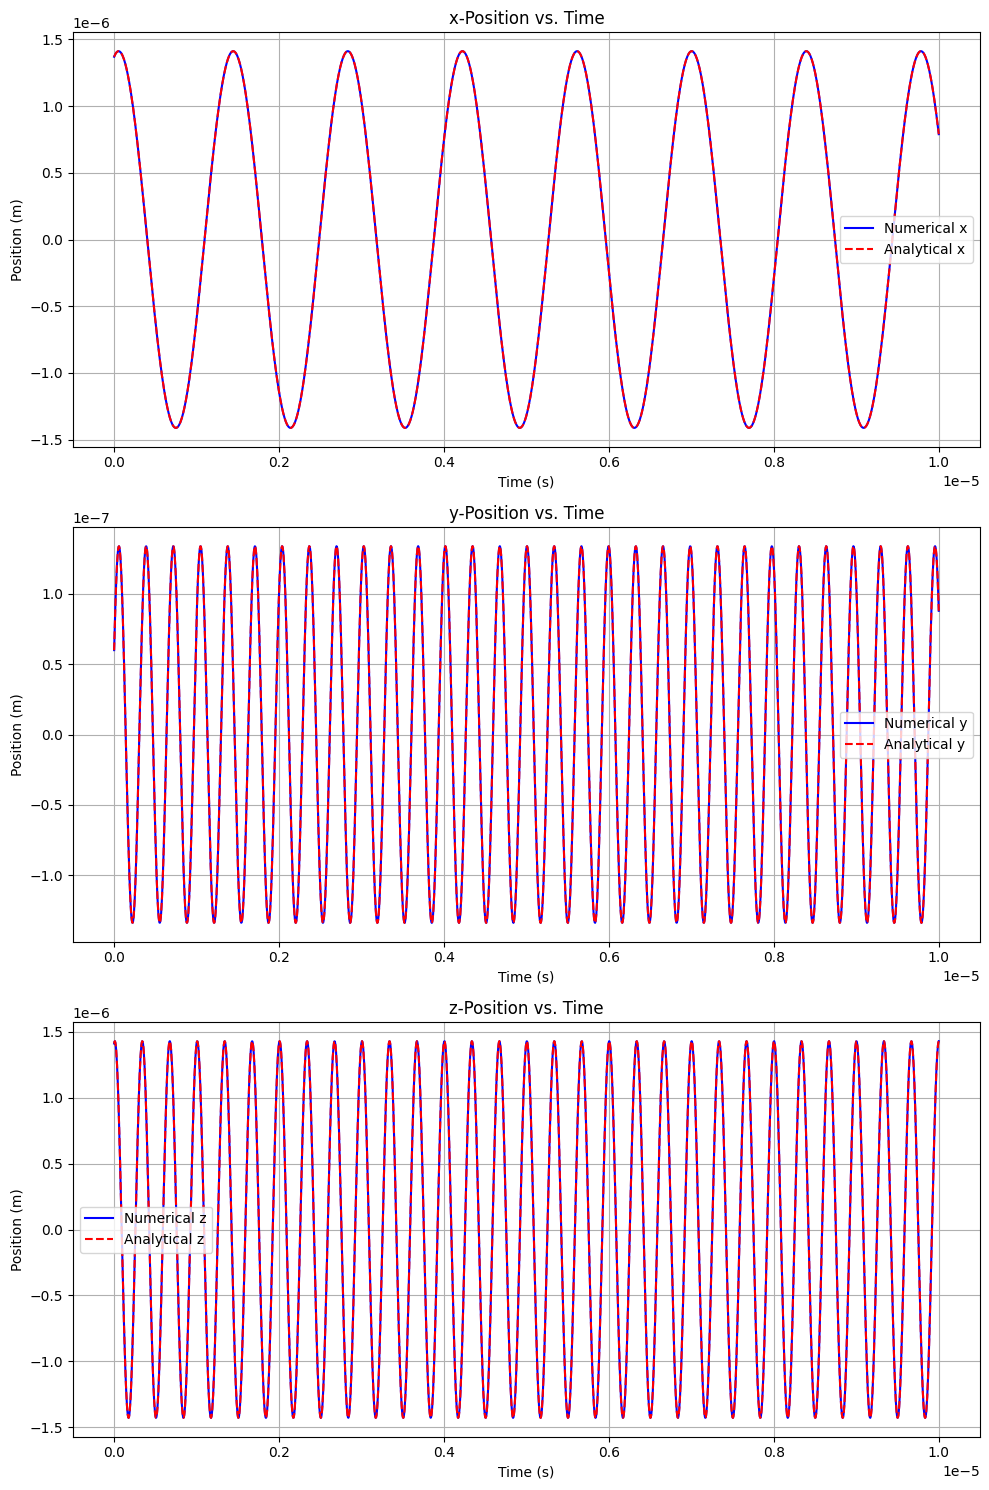

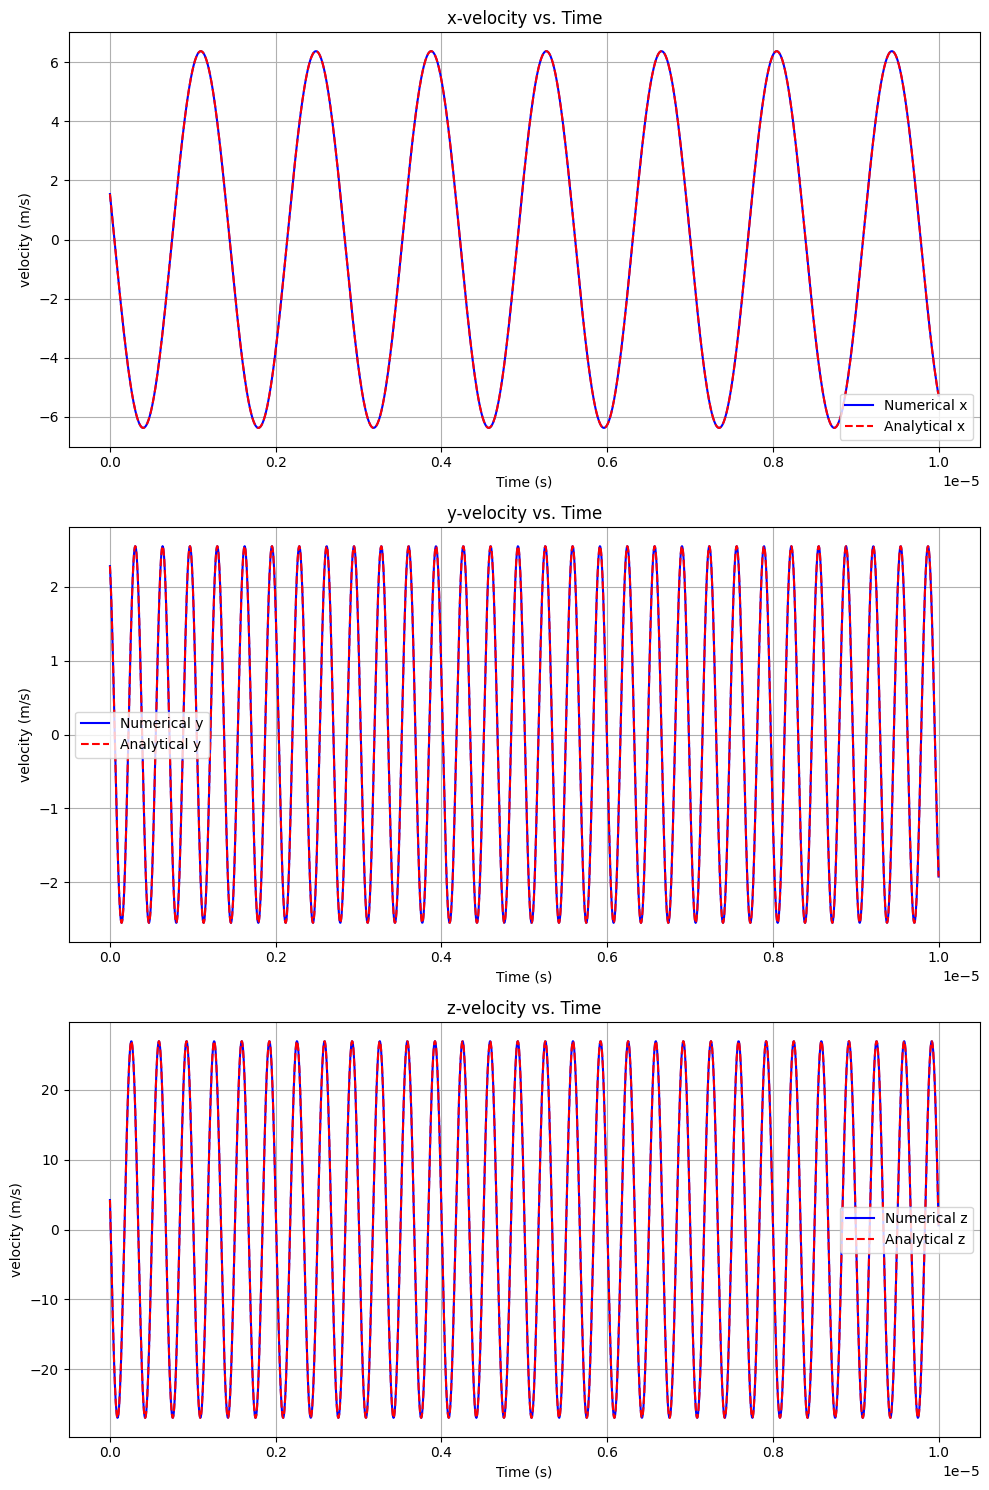

Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1e-05


In [39]:
## 1. Simulate simple harmonic motion of ion in an ion trap
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
omega_original = omega

# Random initial condition x0<2um; v0<5m/s
x1_0 = np.random.randint(0,200)/100*um
x2_0 = np.random.randint(0,200)/100*um
x3_0 = np.random.randint(0,200)/100*um
v1_0 = np.random.randint(0,500)/100
v2_0 = np.random.randint(0,500)/100
v3_0 = np.random.randint(0,500)/100
x0 = [x1_0,x2_0,x3_0] # initial position
v0 = [v1_0,v2_0,v3_0] # initial velocity
U0 = np.array([x0,v0])
U0 = U0.flatten()

# Numerical solution to -(omega^2)x = x''
def fun(t,U):
    x1,x2,x3,v1,v2,v3 = U
    x = U[0:3]
    v = U[3:6]
    dxdt = v
    dvdt = -1*omega**2*x
    return np.concatenate([dxdt,dvdt])

t_eval = np.linspace(0,1e-5,2000)
t_span = (0,1e-5)
sol = solve_ivp(fun,t_span,U0,method='RK45',t_eval=t_eval,dense_output=True,
            rtol=1e-15,
            atol=1e-15)
x1_sol = sol.y[0]
x2_sol = sol.y[1]
x3_sol = sol.y[2]
v1_sol = sol.y[3]
v2_sol = sol.y[4]
v3_sol = sol.y[5]
"""
print(f"x-position: \n {x1_sol}")
print(f"y-position: \n {x2_sol}")
print(f"z-position: \n {x3_sol}")
print(f"x-velocity: \n {v1_sol}")
print(f"y-velocity: \n {v2_sol}")
print(f"z-velocity: \n {v3_sol}")
"""

# Analytical solution
def x_t(omega,x0,v0,t):
    return x0*np.cos(omega*t)+(v0/omega)*np.sin(omega*t)
def v_t(omega,x0,v0,t):
    return -1*omega*x0*np.sin(omega*t)+v0*np.cos(omega*t)
x1_sol_analytic = []
x2_sol_analytic = []
x3_sol_analytic = []
v1_sol_analytic = []
v2_sol_analytic = []
v3_sol_analytic = []
for t in t_eval:
    x1_sol_analytic.append(x_t(omega[0],x1_0,v1_0,t))
    x2_sol_analytic.append(x_t(omega[1],x2_0,v2_0,t))
    x3_sol_analytic.append(x_t(omega[2],x3_0,v3_0,t))
    v1_sol_analytic.append(v_t(omega[0],x1_0,v1_0,t))
    v2_sol_analytic.append(v_t(omega[1],x2_0,v2_0,t))
    v3_sol_analytic.append(v_t(omega[2],x3_0,v3_0,t))
"""
print(f"x-position analytic: \n {x1_sol_analytic}")
print(f"y-position analytic: \n {x2_sol_analytic}")
print(f"z-position analytic: \n {x3_sol_analytic}")
print(f"x-velocity analytic: \n {v1_sol_analytic}")
print(f"y-velocity analytic: \n {v2_sol_analytic}")
print(f"z-velocity analytic: \n {v3_sol_analytic}")
"""

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-position
axes[0].plot(sol.t, x1_sol, 'b-', label='Numerical x')
axes[0].plot(t_eval, x1_sol_analytic, 'r--', label='Analytical x')
axes[0].set_title('x-Position vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].legend()
axes[0].grid(True)

# Plot y-position
axes[1].plot(sol.t, x2_sol, 'b-', label='Numerical y')
axes[1].plot(t_eval, x2_sol_analytic, 'r--', label='Analytical y')
axes[1].set_title('y-Position vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Position (m)')
axes[1].legend()
axes[1].grid(True)

# Plot z-position
axes[2].plot(sol.t, x3_sol, 'b-', label='Numerical z')
axes[2].plot(t_eval, x3_sol_analytic, 'r--', label='Analytical z')
axes[2].set_title('z-Position vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Position (m)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-velocity
axes[0].plot(sol.t, v1_sol, 'b-', label='Numerical x')
axes[0].plot(t_eval, v1_sol_analytic, 'r--', label='Analytical x')
axes[0].set_title('x-velocity vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('velocity (m/s)')
axes[0].legend()
axes[0].grid(True)

# Plot y-velocity
axes[1].plot(sol.t, v2_sol, 'b-', label='Numerical y')
axes[1].plot(t_eval, v2_sol_analytic, 'r--', label='Analytical y')
axes[1].set_title('y-velocity vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()
axes[1].grid(True)

# Plot z-velocity
axes[2].plot(sol.t, v3_sol, 'b-', label='Numerical z')
axes[2].plot(t_eval, v3_sol_analytic, 'r--', label='Analytical z')
axes[2].set_title('z-velocity vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('velocity (m/s)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

## Check solver
print("Success?", sol.success)
print("Message:", sol.message)
print("Final time:", sol.t[-1])


In [30]:
# RF pseudo-force
def FRF(x,y,z,m=c.m,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z_charge*q)/(2*pi*np.sqrt(m)*omrf))**2*np.array([divypartz*0,divzparty+divyparty,divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,x,y,z,v): # gradient term of DC potential
    dy=y-yi
    dx=x-xi
    r = math.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*math.pi))*np.array([divx,divy,divz])

def FDC_single(x1,y1,x2,y2,x,y,z,v):
    return -Z_charge*e * (anatangrad(x2,y2,x,y,z,v)-anatangrad(x2,y1,x,y,z,v)-anatangrad(x1,y2,x,y,z,v)+anatangrad(x1,y1,x,y,z,v))

def FDC(x,y,z,m=c.m,q=c.e,omrf=c.omega,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    z_original = z
    force = np.zeros(3)
    for k in range (0,40):
        if(k!=19 and k!=39):
            z = z-z0
        (x1k,y1k) = xy1k[k]
        (x2k,y2k) = xy2k[k]
        force_single = FDC_single(x1k,y1k,x2k,y2k,x,y,z,vk[k])
        force += force_single
        z = z_original
    return force

Initial DM position: [np.float64(-4.7035062521223136e-05), np.float64(-7.092772516679223e-06), np.float64(-8.79624662663074e-05)]
Initial DM velocity: [np.float64(202.87442795512774), np.float64(-291.37003839683246), np.float64(-352.05889735455924)]
Initial DM position: [np.float64(-4.7035062521223136e-05), np.float64(-7.092772516679223e-06), np.float64(-8.79624662663074e-05)]
Initial DM velocity: [np.float64(202.87442795512774), np.float64(-291.37003839683246), np.float64(-352.05889735455924)]


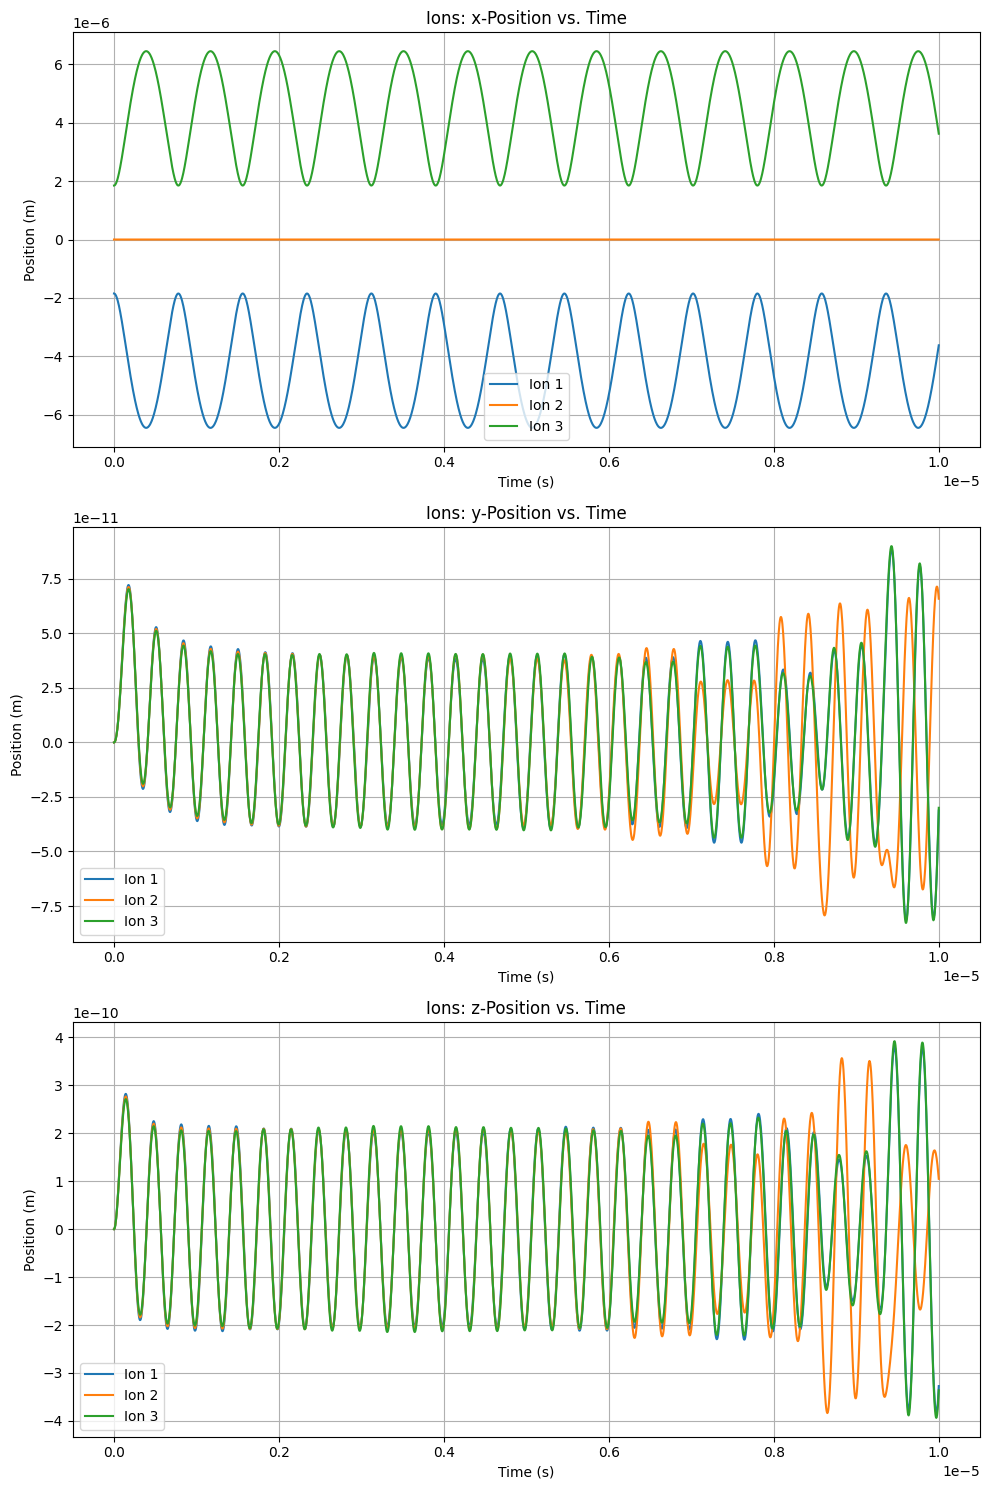

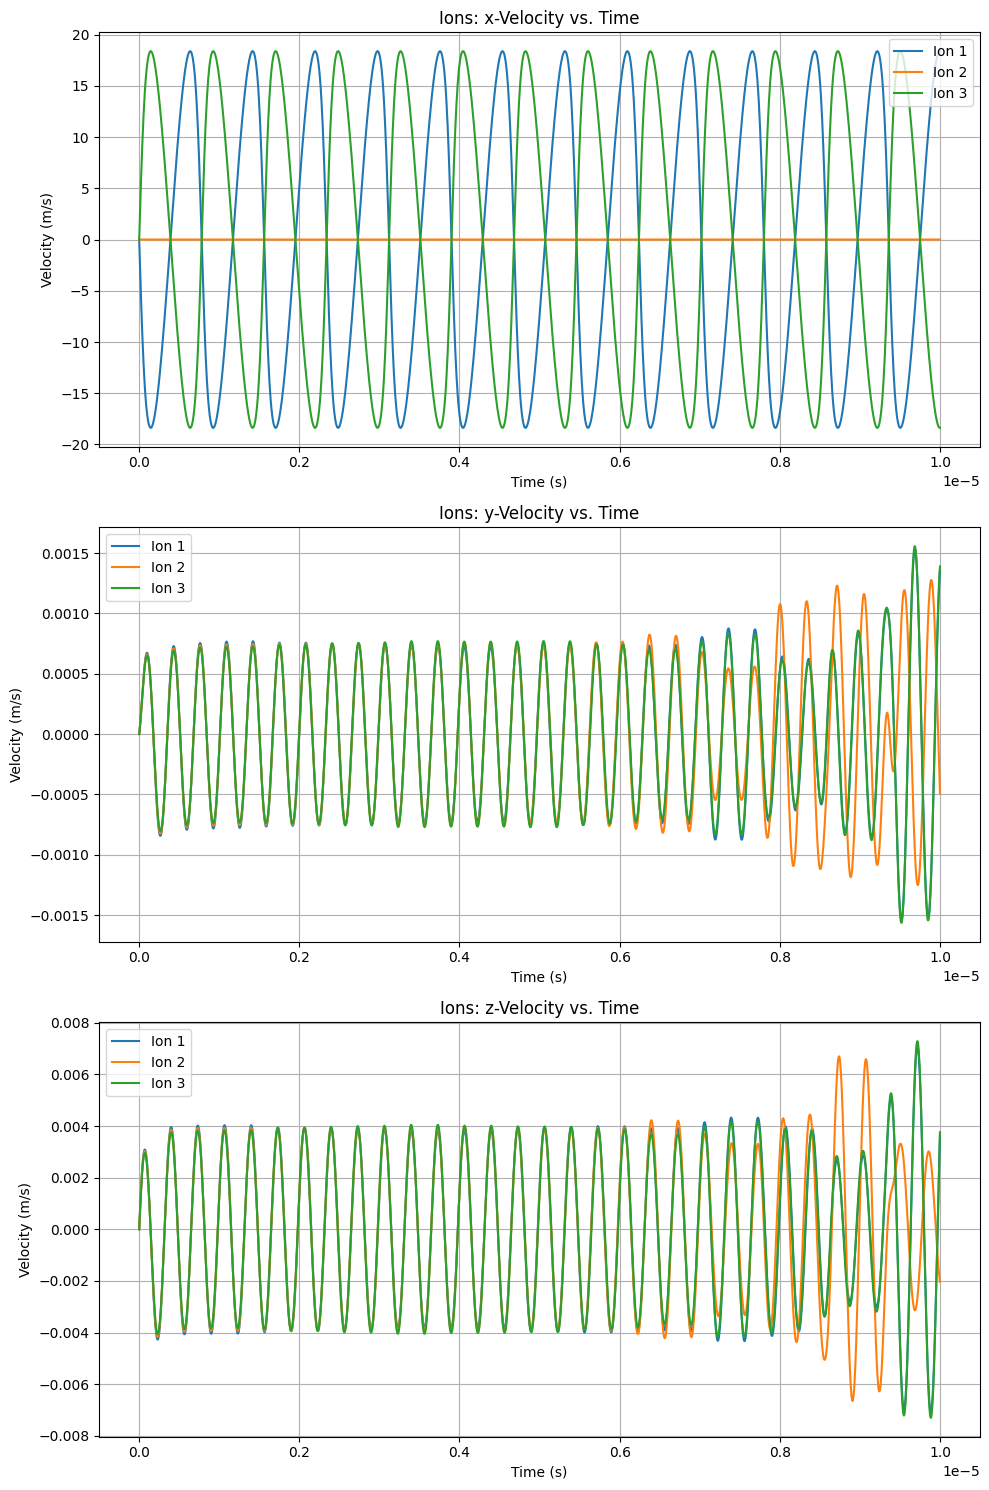

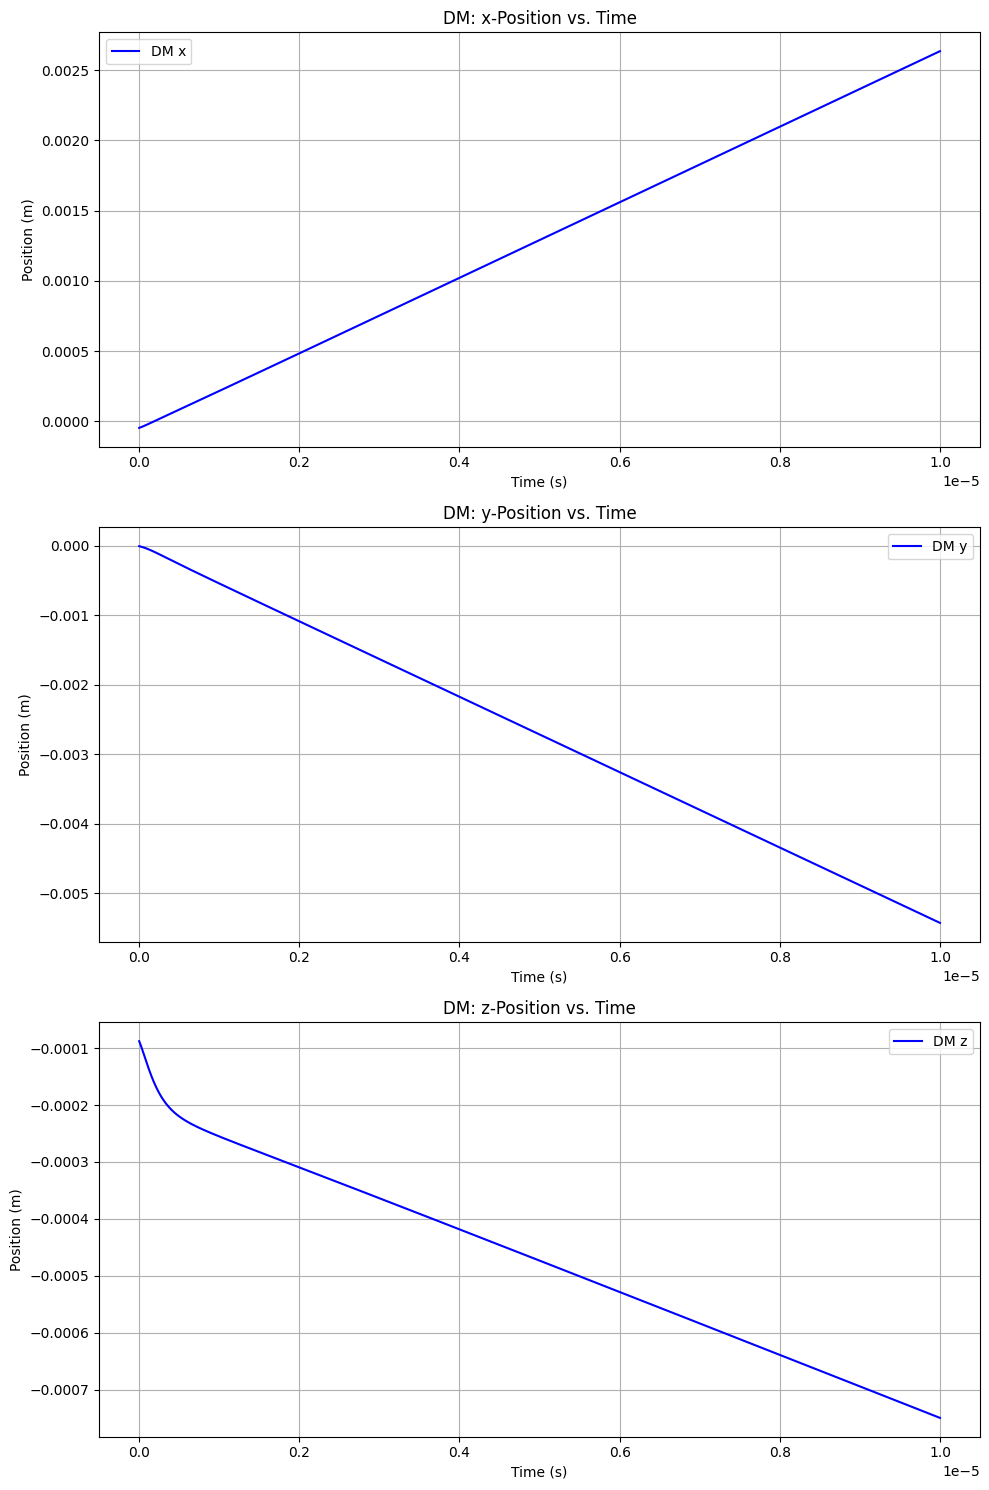

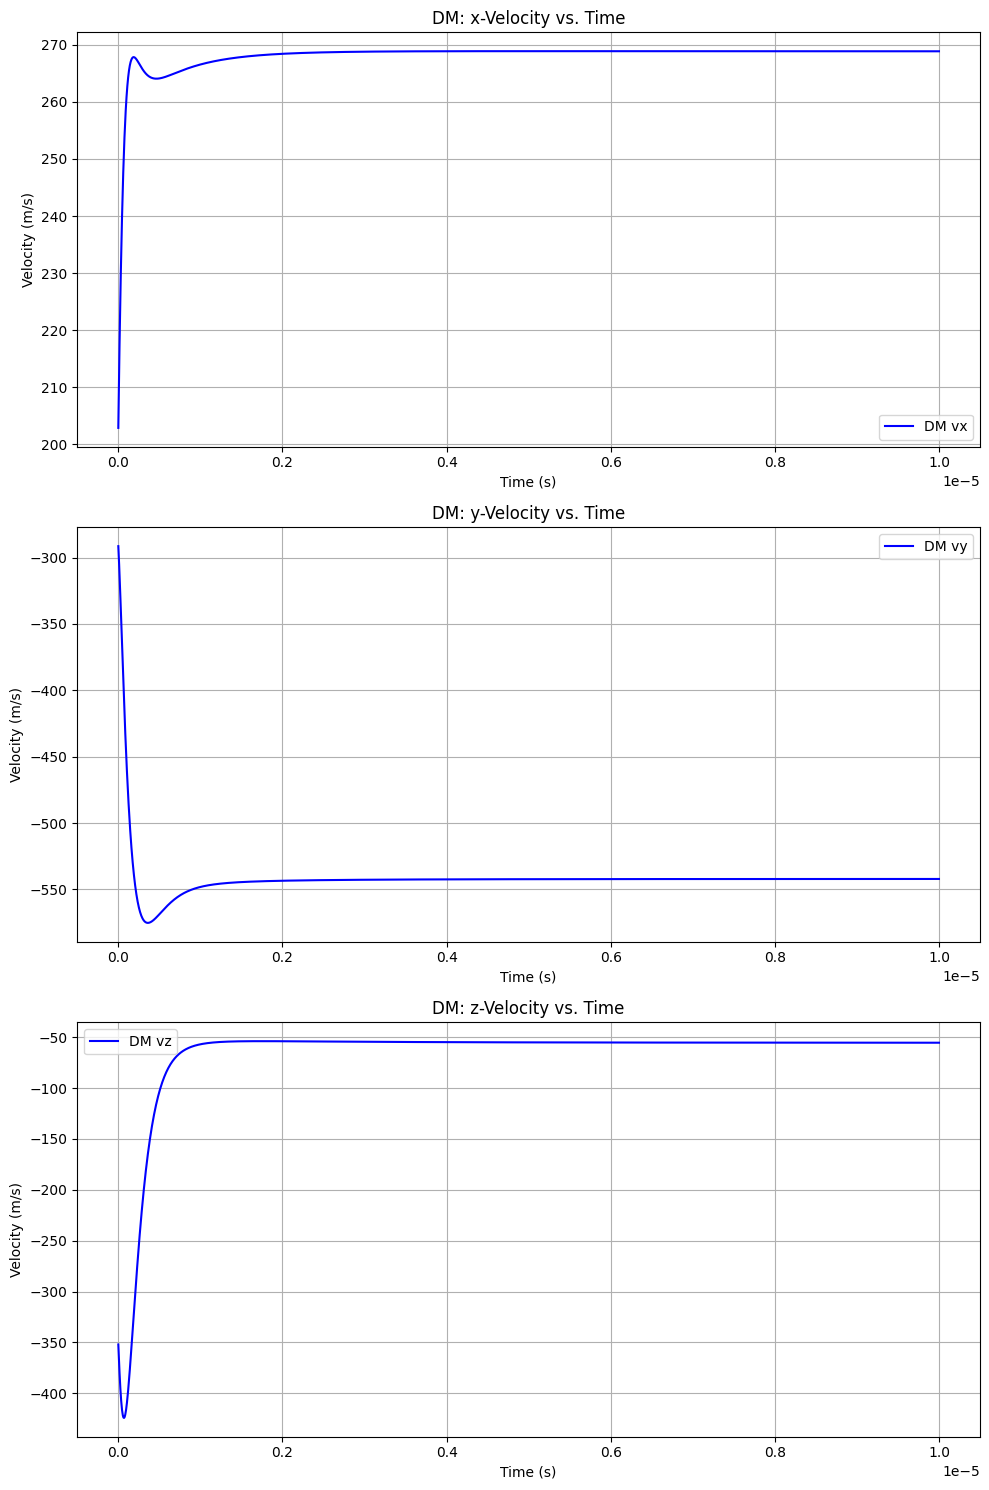

Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1e-05


In [ ]:
## 2. Simulate dark matter trajectory using ion trap potential with random initial condition; check energy conservation
# Initial condition- for ion: rest and equilibrium
d_chain = 3.7e-6  # 3.7 µm separation
x0_ions = np.array([
    [-d_chain/2, 0, 0],
    [0, 0, 0],
    [d_chain/2, 0, 0]
])
v0_ions = np.zeros_like(x0_ions)
# Random initial condition- for DM: r0=100um, v0=500m/s
r_trap = 100*um
speed_dm = 500
phi, theta = np.random.rand(2)*2*pi
phi2, theta2 = np.random.rand(2)*2*pi
x0_dm = [
    r_trap*np.sin(phi)*np.cos(theta),
    r_trap*np.sin(phi)*np.sin(theta),
    r_trap*np.cos(phi)
]
v0_dm = [
    speed_dm*np.sin(phi2)*np.cos(theta2),
    speed_dm*np.sin(phi2)*np.sin(theta2),
    speed_dm*np.cos(phi2)
]
print(f"Initial DM position: {x0_dm}")
print(f"Initial DM velocity: {v0_dm}")
print(f"Initial DM position: {x0_dm}")
print(f"Initial DM velocity: {v0_dm}")
U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm])

# ODE system
def fun2(t,U):
    n_ions = 3
    x_ions = U[0:3*n_ions].reshape((n_ions,3))
    x_dm   = U[3*n_ions:3*n_ions+3]
    v_ions = U[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3))
    v_dm   = U[-3:]

    # Trap field at DM
    dc_force = FDC(*x_dm)
    rf_force = FRF(*x_dm)
    E_trap = (dc_force+rf_force)/e

    # Derivatives
    dx_ionsdt = v_ions
    dv_ionsdt = np.zeros_like(x_ions)

    # Each ion: trap + Coulomb with DM + Coulomb with other ions
    for i in range(n_ions):
        # Trap force
        dv_ionsdt[i] += -omega**2*x_ions[i]

        # Coulomb with DM
        δ = 1e-8
        delta_dm = x_ions[i] - x_dm
        dv_ionsdt[i] += K*eps*e**2*delta_dm/(m_ion*(np.linalg.norm(delta_dm)+δ)**3)

        # Coulomb with other ions
        for j in range(n_ions):
            if i != j:
                delta_ij = x_ions[i] - x_ions[j]
                dv_ionsdt[i] += K*e**2*delta_ij/(m_ion*np.linalg.norm(delta_ij)**3)

    # DM motion
    dx_dmdt = v_dm
    dv_dmdt = -eps*e*E_trap/m_dm

    # DM Coulomb with all ions
    for i in range(n_ions):
        delta_dm = x_dm - x_ions[i]
        dv_dmdt += -K*eps*e**2*delta_dm/(m_dm*np.linalg.norm(delta_dm)**3)

    return np.concatenate([
        dx_ionsdt.flatten(), dx_dmdt,
        dv_ionsdt.flatten(), dv_dmdt
    ])

# Solve system
t_eval = np.linspace(0,1e-5,2000)
t_span = (0,1e-5)
sol = solve_ivp(
    fun2, t_span, U0, method='DOP853',
    t_eval=t_eval, dense_output=True,
    rtol=1e-11, atol=1e-11
)

# Extract solutions
n_ions = 3
x_ions_sol = sol.y[0:3*n_ions].reshape((n_ions,3,-1))
x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]
v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3,-1))
v_dm_sol   = sol.y[-3:]

"""
# Solve coupled equations of motion
def fun2(t,U):
    x_ion = U[0:3]
    x_dm = U[3:6]
    v_ion = U[6:9]
    v_dm = U[9:12]
    dc_force = FDC(*x_dm)
    rf_force = FRF(*x_dm)
    E_trap = (dc_force+rf_force)/e
    delta_r = x_ion - x_dm
    dx_iondt = v_ion
    dv_iondt = -omega**2*x_ion+K*eps*e**2*delta_r/(m_ion*np.linalg.norm(delta_r)**3)
    dx_dmdt = v_dm
    dv_dmdt = -eps*e*E_trap/m_dm-K*eps*e**2*delta_r/(m_dm*np.linalg.norm(delta_r)**3)
    return np.concatenate([dx_iondt,dx_dmdt,dv_iondt,dv_dmdt])
"""

## Plots for ions
fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z positions
for i in range(n_ions):
    axes[0].plot(sol.t, x_ions_sol[i,0], label=f'Ion {i+1}')
    axes[1].plot(sol.t, x_ions_sol[i,1], label=f'Ion {i+1}')
    axes[2].plot(sol.t, x_ions_sol[i,2], label=f'Ion {i+1}')

axes[0].set_title('Ions: x-Position vs. Time')
axes[1].set_title('Ions: y-Position vs. Time')
axes[2].set_title('Ions: z-Position vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (m)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z velocities
for i in range(n_ions):
    axes[0].plot(sol.t, v_ions_sol[i,0], label=f'Ion {i+1}')
    axes[1].plot(sol.t, v_ions_sol[i,1], label=f'Ion {i+1}')
    axes[2].plot(sol.t, v_ions_sol[i,2], label=f'Ion {i+1}')

axes[0].set_title('Ions: x-Velocity vs. Time')
axes[1].set_title('Ions: y-Velocity vs. Time')
axes[2].set_title('Ions: z-Velocity vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## Plots for dark matter
fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z positions
axes[0].plot(sol.t, x_dm_sol[0], 'b-', label='DM x')
axes[1].plot(sol.t, x_dm_sol[1], 'b-', label='DM y')
axes[2].plot(sol.t, x_dm_sol[2], 'b-', label='DM z')

axes[0].set_title('DM: x-Position vs. Time')
axes[1].set_title('DM: y-Position vs. Time')
axes[2].set_title('DM: z-Position vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (m)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z velocities
axes[0].plot(sol.t, v_dm_sol[0], 'b-', label='DM vx')
axes[1].plot(sol.t, v_dm_sol[1], 'b-', label='DM vy')
axes[2].plot(sol.t, v_dm_sol[2], 'b-', label='DM vz')

axes[0].set_title('DM: x-Velocity vs. Time')
axes[1].set_title('DM: y-Velocity vs. Time')
axes[2].set_title('DM: z-Velocity vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## Check solver
print("Success?", sol.success)
print("Message:", sol.message)
print("Final time:", sol.t[-1])

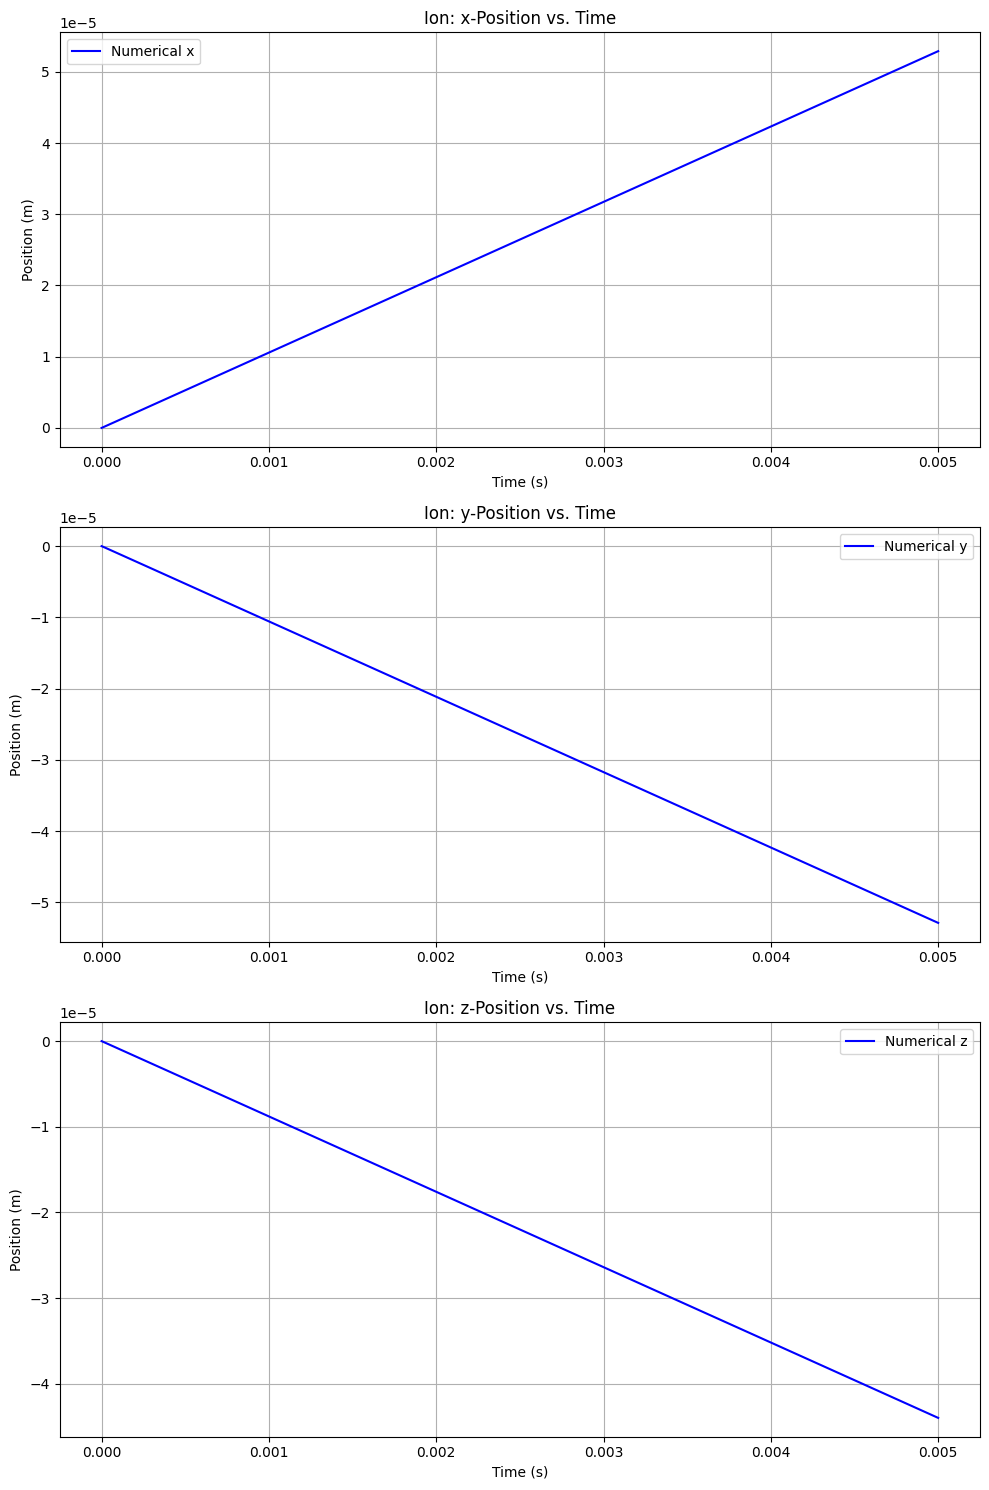

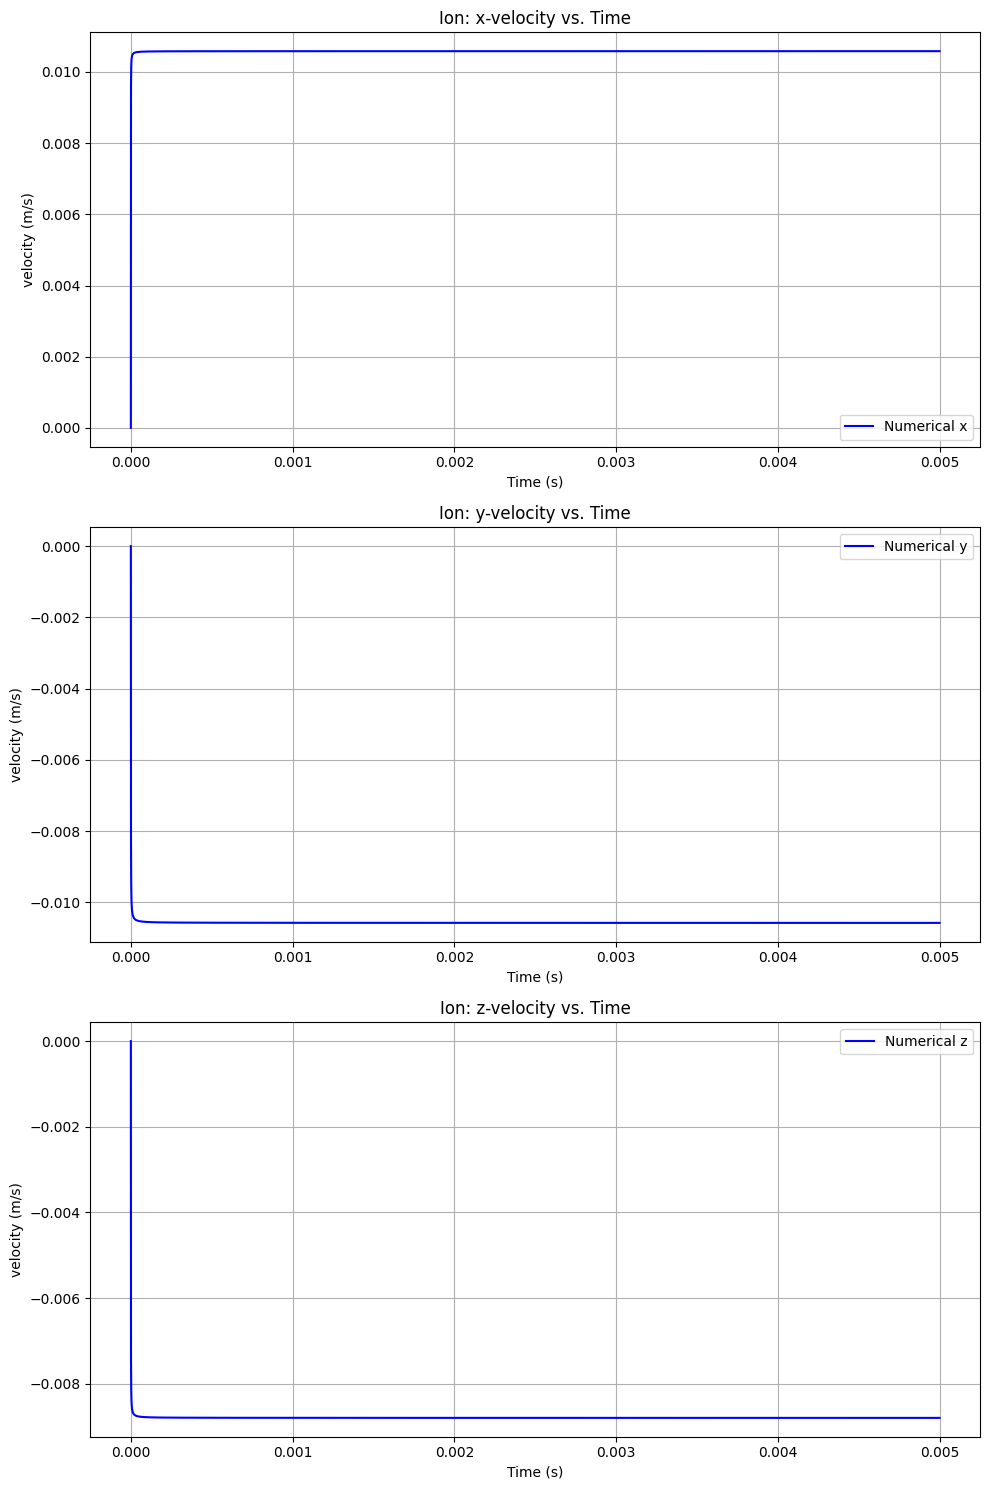

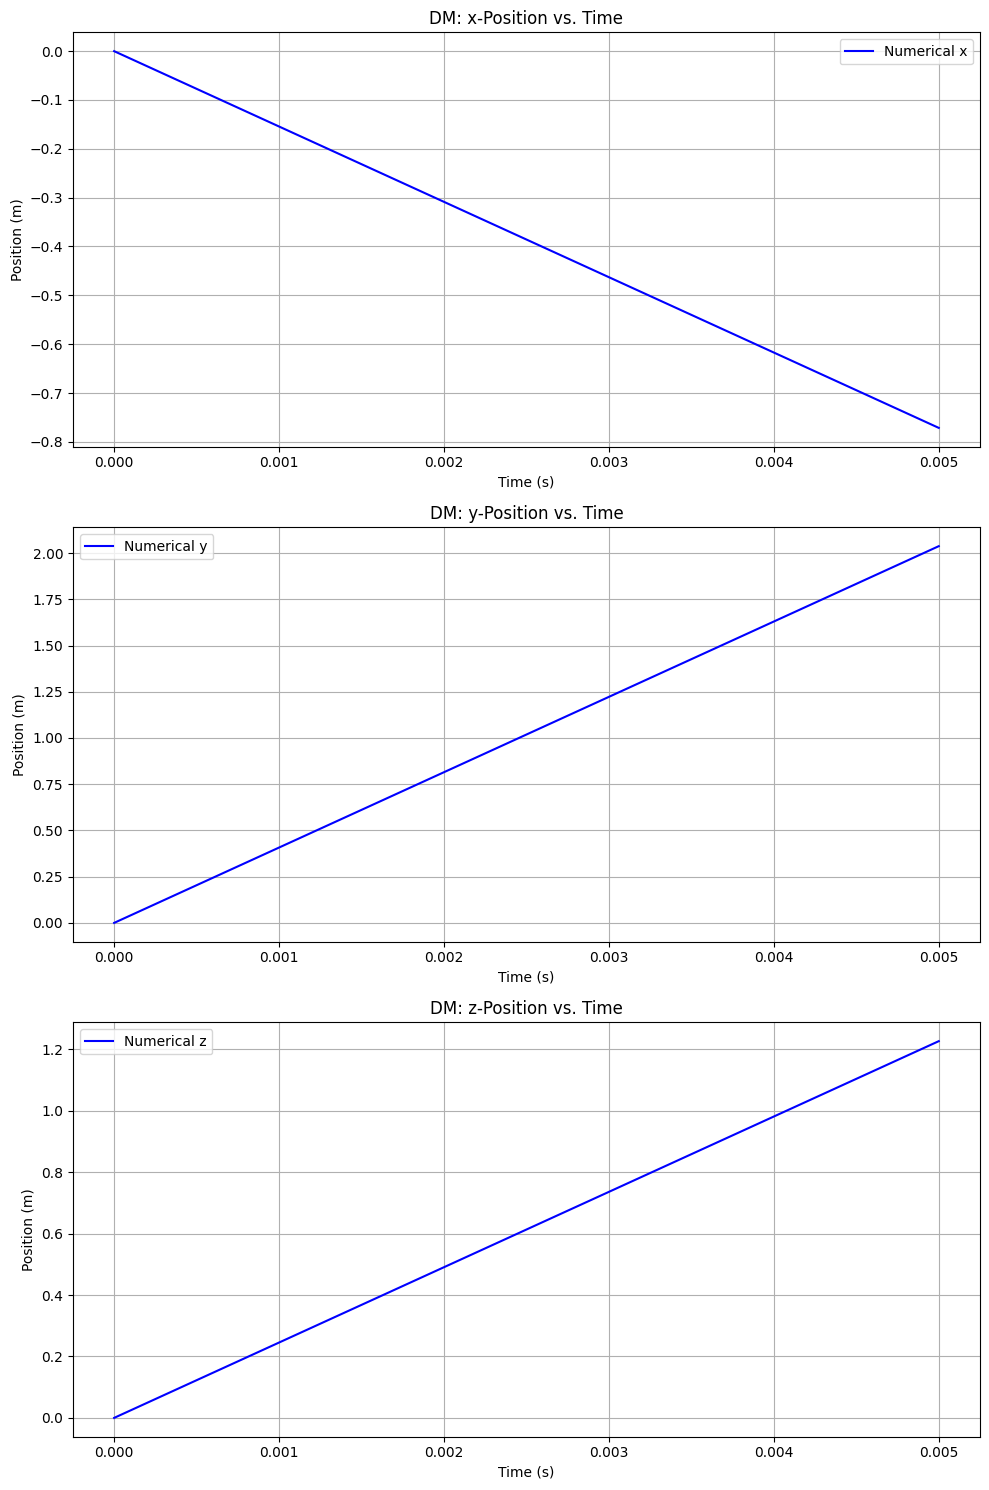

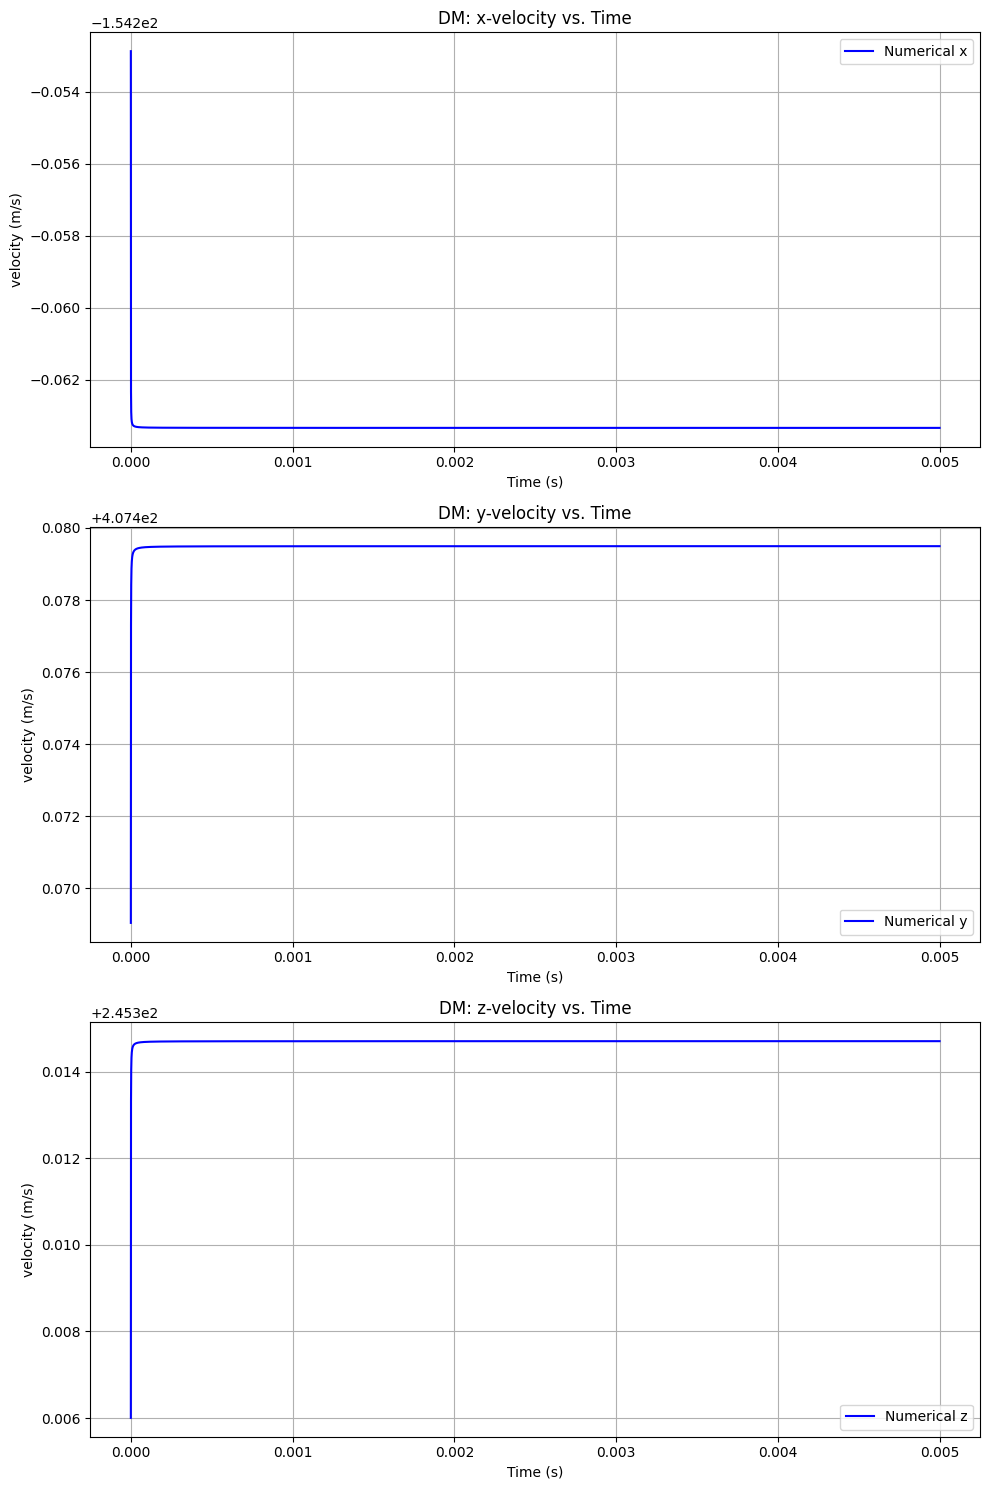

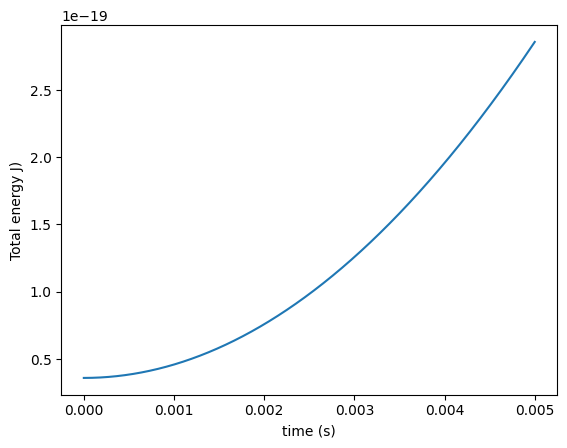

<Figure size 640x480 with 0 Axes>

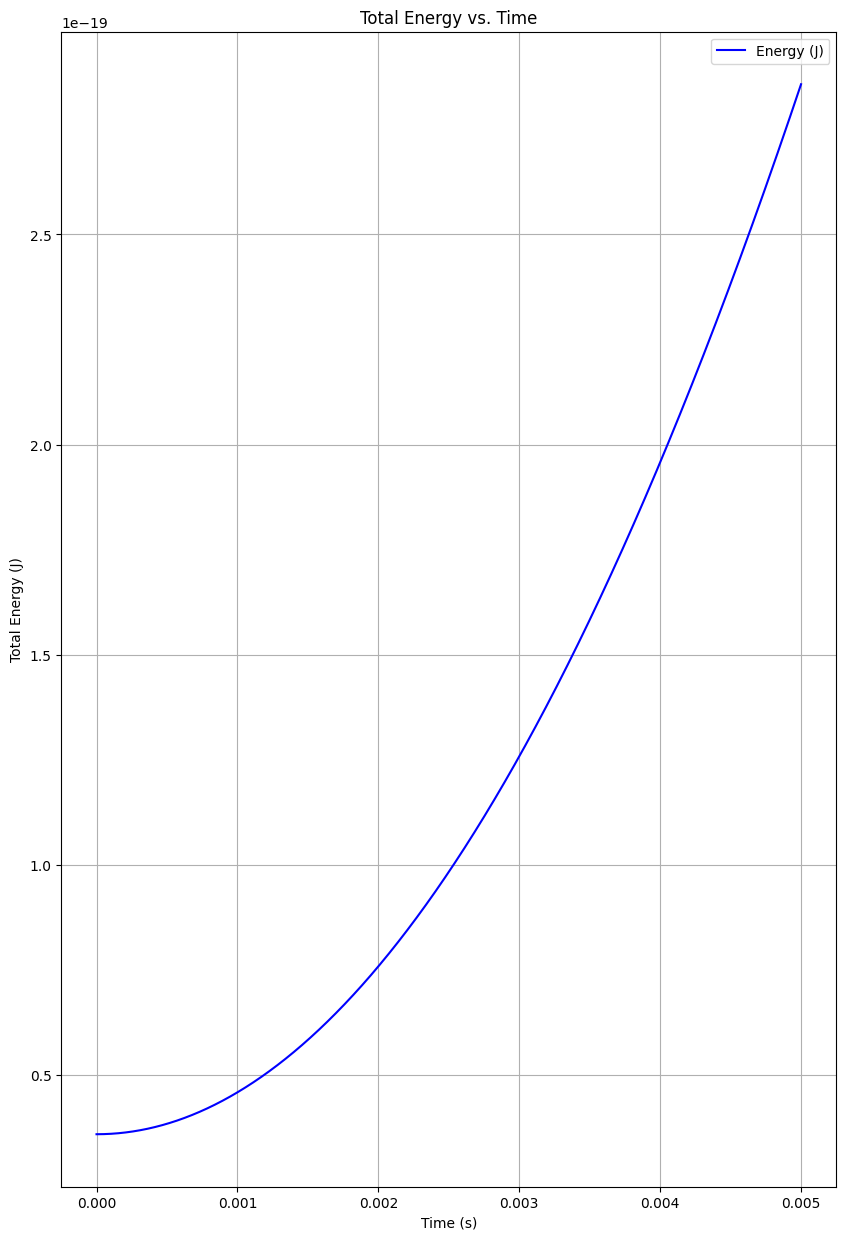

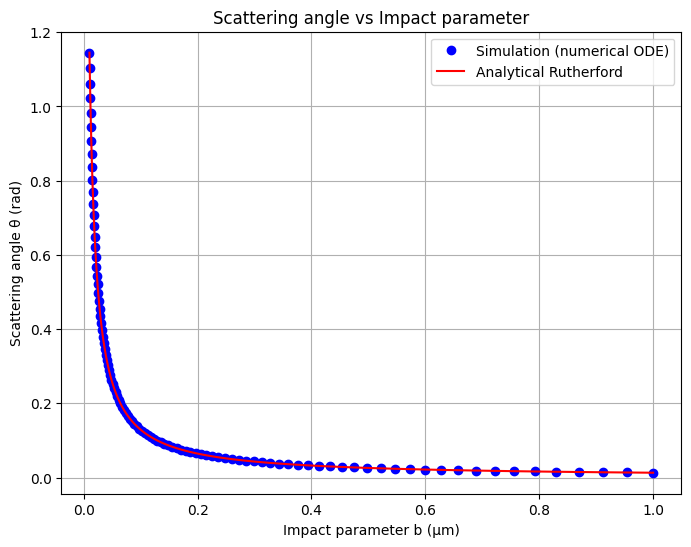

In [ ]:
## 3. Simulate Rutherford scattering without the potential; use an ODE package to solve a coupled system
# Initial condition- for ion: rest and equilibrium
x0_ion = [0,0,0] # initial position
v0_ion = [0,0,0] # initial velocity

# Random initial condition- for DM: r0=100um, v0=500m/s
r_trap = 1*cm
speed_dm = 500 
b_list = np.logspace(-8, -6, 100)  # 10 nm to 1 µm
U0 = np.array([x0_ion,x0_dm,v0_ion,v0_dm])
U0 = U0.flatten()

# Solve coupled equations of motion
def fun2(t,U):
    x_ion = U[0:3]
    x_dm = U[3:6]
    v_ion = U[6:9]
    v_dm = U[9:12]
    E_trap = 0; # without trap potential 
    omega = 0; # without trap potential
    delta_r = x_ion - x_dm
    dx_iondt = v_ion
    dv_iondt = -omega**2*x_ion+K*eps*e**2*delta_r/(m_ion*np.linalg.norm(delta_r)**3)
    dx_dmdt = v_dm
    dv_dmdt = -eps*e*E_trap/m_dm-K*eps*e**2*delta_r/(m_dm*np.linalg.norm(delta_r)**3)
    return np.concatenate([dx_iondt,dx_dmdt,dv_iondt,dv_dmdt])

## Sample trajectory
t_span = (0, 5e-3)
t_eval = np.linspace(0, 5e-3, 20000)
sol = solve_ivp(fun2,t_span,U0,method='DOP853',t_eval=t_eval,dense_output=True,
            rtol=1e-11,
            atol=1e-11)
x1_ion_sol = sol.y[0]
x2_ion_sol = sol.y[1]
x3_ion_sol = sol.y[2]
x1_dm_sol = sol.y[3]
x2_dm_sol = sol.y[4]
x3_dm_sol = sol.y[5]
v1_ion_sol = sol.y[6]
v2_ion_sol = sol.y[7]
v3_ion_sol = sol.y[8]
v1_dm_sol = sol.y[9]
v2_dm_sol = sol.y[10]
v3_dm_sol = sol.y[11]

## Plots for ion
fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-position
axes[0].plot(sol.t, x1_ion_sol, 'b-',label='Numerical x')
axes[0].set_title('Ion: x-Position vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].legend()
axes[0].grid(True)

# Plot y-position
axes[1].plot(sol.t, x2_ion_sol, 'b-',label='Numerical y')
axes[1].set_title('Ion: y-Position vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Position (m)')
axes[1].legend()
axes[1].grid(True)

# Plot z-position
axes[2].plot(sol.t, x3_ion_sol, 'b-',label='Numerical z')
axes[2].set_title('Ion: z-Position vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Position (m)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-velocity
axes[0].plot(sol.t, v1_ion_sol, 'b-',label='Numerical x')
axes[0].set_title('Ion: x-velocity vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('velocity (m/s)')
axes[0].legend()
axes[0].grid(True)

# Plot y-velocity
axes[1].plot(sol.t, v2_ion_sol, 'b-',label='Numerical y')
axes[1].set_title('Ion: y-velocity vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()
axes[1].grid(True)

# Plot z-velocity
axes[2].plot(sol.t, v3_ion_sol, 'b-',label='Numerical z')
axes[2].set_title('Ion: z-velocity vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('velocity (m/s)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

## Plots for dark matter
fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-position
axes[0].plot(sol.t, x1_dm_sol, 'b-',label='Numerical x')
axes[0].set_title('DM: x-Position vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].legend()
axes[0].grid(True)

# Plot y-position
axes[1].plot(sol.t, x2_dm_sol, 'b-',label='Numerical y')
axes[1].set_title('DM: y-Position vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Position (m)')
axes[1].legend()
axes[1].grid(True)

# Plot z-position
axes[2].plot(sol.t, x3_dm_sol, 'b-',label='Numerical z')
axes[2].set_title('DM: z-Position vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Position (m)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-velocity
axes[0].plot(sol.t, v1_dm_sol, 'b-',label='Numerical x')
axes[0].set_title('DM: x-velocity vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('velocity (m/s)')
axes[0].legend()
axes[0].grid(True)

# Plot y-velocity
axes[1].plot(sol.t, v2_dm_sol, 'b-',label='Numerical y')
axes[1].set_title('DM: y-velocity vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()
axes[1].grid(True)

# Plot z-velocity
axes[2].plot(sol.t, v3_dm_sol, 'b-',label='Numerical z')
axes[2].set_title('DM: z-velocity vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('velocity (m/s)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

## Check energy conservation
v_ion = np.vstack([v1_ion_sol, v2_ion_sol, v3_ion_sol]).T
v_dm  = np.vstack([v1_dm_sol, v2_dm_sol, v3_dm_sol]).T
x_ion = np.vstack([x1_ion_sol, x2_ion_sol, x3_ion_sol]).T
x_dm  = np.vstack([x1_dm_sol, x2_dm_sol, x3_dm_sol]).T

kin_ion = 0.5 * m_ion * np.sum(v_ion**2, axis=1)
kin_dm  = 0.5 * m_dm  * np.sum(v_dm**2, axis=1)
pot_trap = 0.5 * m_ion * np.sum((omega_original**2) * (x_ion**2), axis=1)
r = np.linalg.norm(x_ion - x_dm, axis=1)
pot_coulomb = eps * K * e**2 / r

E_total = kin_ion + kin_dm + pot_trap + pot_coulomb

plt.plot(sol.t, E_total)
plt.xlabel("time (s)")
plt.ylabel("Total energy J)")
plt.show()

## Compare to analytical Rutherford formula
# Helper: compute CM-frame scattering angle from a single trajectory
def scattering_angle_cm(sol):
    
    """
    Extract θ_cm from a solve_ivp solution by comparing initial and final
    relative velocity vectors v_rel = v_dm - v_ion.
    """
    # velocities over time
    v1_ion, v2_ion, v3_ion = sol.y[6], sol.y[7], sol.y[8]
    v1_dm,  v2_dm,  v3_dm  = sol.y[9], sol.y[10], sol.y[11]

    v_rel0 = np.array([v1_dm[0] - v1_ion[0],
                       v2_dm[0] - v2_ion[0],
                       v3_dm[0] - v3_ion[0]])
    v_relF = np.array([v1_dm[-1] - v1_ion[-1],
                       v2_dm[-1] - v2_ion[-1],
                       v3_dm[-1] - v3_ion[-1]])
    # angle between initial and final relative velocities
    num = np.dot(v_relF, v_rel0)
    den = np.linalg.norm(v_relF) * np.linalg.norm(v_rel0)
    # numerical guard
    cos_theta = np.clip(num / den, -1.0, 1.0)
    return np.arccos(cos_theta)

def run_one_event(r_trap, speed_dm, b):
    x0_dm = [-r_trap,b,0] # initial position
    v0_dm = [speed_dm,0,0] # initial velocity
    # --- Full 12-element initial state expected by fun2 ---
    U0 = np.concatenate([x0_ion, x0_dm, v0_ion, v0_dm])  # shape (12,)
    # --- Solve ---
    sol = solve_ivp(fun2, t_span, U0, method='DOP853', t_eval=t_eval,
                    rtol=1e-9, atol=1e-12)
    return sol

# Compute E_cm from initial state (must match the ODE’s coupling)
def initial_E_cm(sol):
    # masses
    mu = (m_dm*m_ion)/(m_dm + m_ion)
    v1_ion0, v2_ion0, v3_ion0 = sol.y[6,0], sol.y[7,0], sol.y[8,0]
    v1_dm0,  v2_dm0,  v3_dm0  = sol.y[9,0], sol.y[10,0], sol.y[11,0]
    v_rel0 = np.array([v1_dm0 - v1_ion0, v2_dm0 - v2_ion0, v3_dm0 - v3_ion0])
    return 0.5*mu*np.dot(v_rel0, v_rel0)

## ----- Run an ensemble of scattering events -----
thetas = []
for i in range(0,len(b_list)):
    # Run one ODE event
    b = b_list[i]
    sol = run_one_event(r_trap,speed_dm,b)
    
    # Extract scattering angle from trajectory
    theta_cm = scattering_angle_cm(sol)
    thetas.append(theta_cm)
thetas = np.array(thetas)

## Plot total energy
plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()
fig, axes = plt.subplots(1, 1, figsize=(10, 15))
axes.plot(sol.t, E_total, 'b-',label='Energy (J)')
axes.set_title('Total Energy vs. Time')
axes.set_xlabel('Time (s)')
axes.set_ylabel('Total Energy (J)')
axes.legend()
axes.grid(True)

# --- Parameters for analytic curve ---
q1 = e          # charge of ion
q2 = eps * e    # charge of DM particle (adjust if different)
mu = (m_dm*m_ion)/(m_dm + m_ion)  # reduced mass
E = 0.5*mu*speed_dm**2
C = K * q1 * q2

# --- Analytical scattering curve ---
b_nonzero = b_list.copy()
b_nonzero[b_nonzero == 0] = np.nan   # avoid division by zero
thetas_analytic = 2*np.arctan(C/(2*E*b_nonzero))

# --- Plot comparison ---
plt.figure(figsize=(8,6))
plt.plot(b_list*1e6, thetas, 'bo', label="Simulation (numerical ODE)")
plt.plot(b_list*1e6, thetas_analytic, 'r-', label="Analytical Rutherford")
plt.xlabel("Impact parameter b (µm)")
plt.ylabel("Scattering angle θ (rad)")
plt.title("Scattering angle vs Impact parameter")
plt.legend()
plt.grid(True)
plt.show()